<a href="https://colab.research.google.com/github/manikandan2505-bit/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026–2027 – Major Project

### Project Overview

This project analyzes agricultural performance across different seasons
using data analytics, statistical techniques and visualization.

The analysis focuses on:

- Seasonal agricultural performance
- Crop-wise performance
- Environmental conditions
- Resource utilization
- Irrigation methods
- Water efficiency
- Production and yield
- Revenue, cost and profit
- Disease and pest risk
- Relationships between agricultural variables

## Objectives

The primary objective of this project is to analyze agricultural data
from different seasons and identify meaningful patterns, trends,
relationships and differences in agricultural performance.

### Specific Objectives

1. Explore and understand the dataset.
2. Clean and prepare the data.
3. Compare agricultural performance across seasons.
4. Analyze environmental conditions across seasons.
5. Examine crop-wise seasonal performance.
6. Analyze irrigation methods and water efficiency.
7. Compare economic outcomes across seasons.
8. Identify relationships between agricultural variables.
9. Apply appropriate statistical techniques.
10. Develop evidence-based conclusions and recommendations.

## Problem Statement

Agricultural activities are influenced by seasonal variations in
environmental conditions, farming practices, resource availability
and market conditions.

As a result, agricultural performance may differ from one season
to another.

However, raw agricultural data does not clearly explain how
agricultural performance changes across seasons or what patterns
can be observed under different seasonal conditions.

Therefore, this project analyzes the given agricultural dataset
to identify meaningful seasonal patterns, trends, relationships
and variations in agricultural performance.

In [1]:
# Seasonal Agriculture Performance Analysis
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

import os
import warnings

warnings.filterwarnings("ignore")

# Create output directory
os.makedirs("agriculture_results", exist_ok=True)

In [2]:
# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 records:")
display(df.head())

Dataset loaded successfully!
Shape: (4000, 28)

First 5 records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Dataset Description

The dataset contains agricultural records covering different:

- Seasons
- States
- Districts
- Crops
- Irrigation methods
- Environmental conditions
- Agricultural inputs
- Production metrics
- Economic metrics

The dataset is used to investigate how agricultural performance
varies across seasonal conditions.

## Data Cleaning and Preparation

The dataset was inspected for:

- Missing values
- Duplicate records
- Incorrect data types
- Numerical and categorical variables
- Potential outliers

Missing numerical values were handled using median imputation
to reduce the effect of extreme values.

In [3]:
# ------------------------------------------------------------
# 3. BASIC DATASET INFORMATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [4]:
# ------------------------------------------------------------
# 4. CHECK MISSING VALUES
# ------------------------------------------------------------

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing Values:")
print(missing)


Missing Values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [5]:
# ------------------------------------------------------------
# 5. DATA CLEANING
# ------------------------------------------------------------

# Make a copy
data = df.copy()

# Numeric columns
numeric_columns = data.select_dtypes(
    include=["int64", "float64"]
).columns

# Fill missing numeric values using median
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

print("\nMissing values after cleaning:")
print(data.isnull().sum().sum())



Missing values after cleaning:
0


In [6]:
# ------------------------------------------------------------
# 6. BASIC DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
display(data.describe().T)



Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [7]:
# ------------------------------------------------------------
# 7. DATASET DISTRIBUTION
# ------------------------------------------------------------

print("\nSeason Distribution:")
print(data["Season"].value_counts())

print("\nCrop Distribution:")
print(data["Crop"].value_counts())

print("\nState Distribution:")
print(data["State"].value_counts())

print("\nIrrigation Method Distribution:")
print(data["Irrigation_Method"].value_counts())


Season Distribution:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop Distribution:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

State Distribution:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Irrigation Method Distribution:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. SEASONAL PERFORMANCE ANALYSIS
# ============================================================

season_summary = data.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Average_Risk=("Disease_Pest_Risk_pct", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean")
).round(2)

print("\nSeasonal Performance:")
display(season_summary)



Seasonal Performance:


,Farms,Median_Yield,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Risk,Average_Rainfall,Average_Temperature
Season,,,,,,,,,,,,
Kharif,1779,1.94,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47,849.20,28.45
Rabi,1627,1.67,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48,437.62,23.49
Zaid,594,1.46,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22,304.65,31.04


In [9]:

# ------------------------------------------------------------
# 9. PROFITABLE FARM PERCENTAGE
# ------------------------------------------------------------

data["Profitable"] = data["Profit_INR"] > 0

profitable_percentage = (
    data.groupby("Season")["Profitable"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nProfitable Farms (%):")
print(profitable_percentage)



Profitable Farms (%):
Season
Kharif    57.79
Rabi      48.86
Zaid      35.52
Name: Profitable, dtype: float64


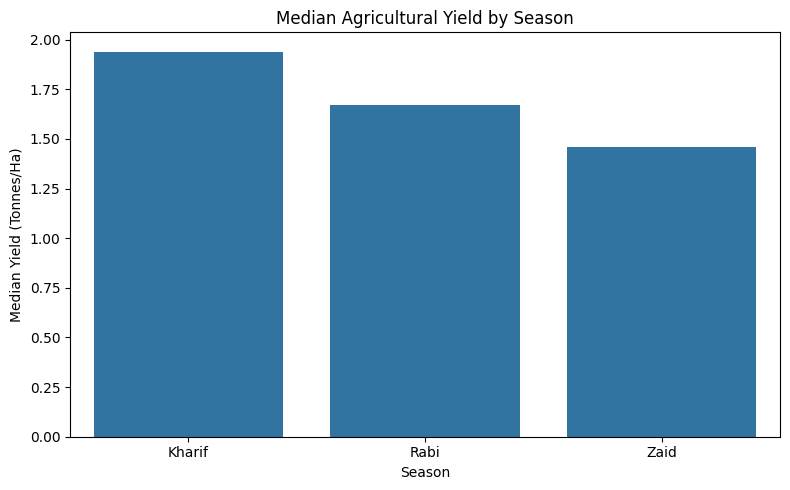

In [10]:
# ============================================================
# 10. CHART 1 - MEDIAN YIELD BY SEASON
# ============================================================

plt.figure(figsize=(8, 5))

season_order = ["Kharif", "Rabi", "Zaid"]

sns.barplot(
    data=data,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order,
    estimator=np.median,
    errorbar=None
)

plt.title("Median Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Median Yield (Tonnes/Ha)")
plt.tight_layout()

plt.savefig(
    "agriculture_results/01_median_yield_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

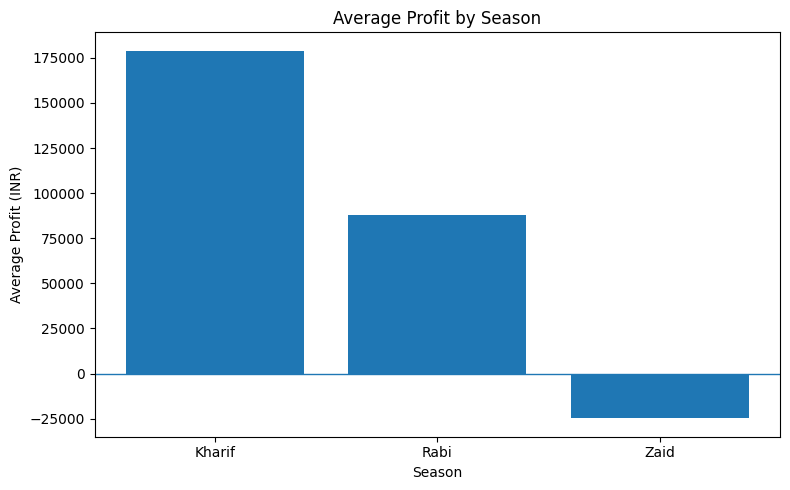

In [11]:

# ============================================================
# 11. CHART 2 - AVERAGE PROFIT BY SEASON
# ============================================================

plt.figure(figsize=(8, 5))

profit_values = (
    data.groupby("Season")["Profit_INR"]
    .mean()
    .reindex(season_order)
)

plt.bar(
    profit_values.index,
    profit_values.values
)

plt.axhline(0, linewidth=1)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()

plt.savefig(
    "agriculture_results/02_average_profit_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


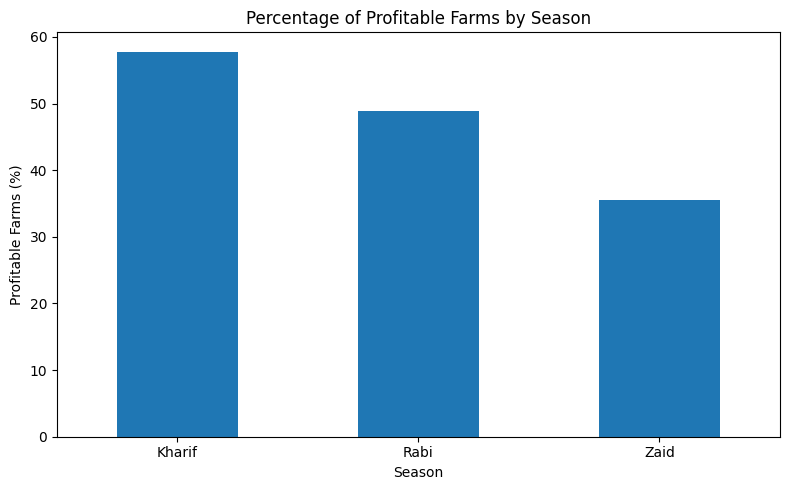

In [12]:
# ============================================================
# 12. CHART 3 - PROFITABLE FARM PERCENTAGE
# ============================================================

plt.figure(figsize=(8, 5))

profitable_percentage.reindex(season_order).plot(
    kind="bar"
)

plt.title("Percentage of Profitable Farms by Season")
plt.xlabel("Season")
plt.ylabel("Profitable Farms (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "agriculture_results/03_profitable_farms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ============================================================
# 13. ENVIRONMENTAL ANALYSIS
# ============================================================

environment_summary = data.groupby("Season").agg(
    Rainfall=("Rainfall_mm", "mean"),
    Temperature=("Avg_Temperature_C", "mean"),
    Humidity=("Humidity_pct", "mean"),
    Sunlight=("Sunlight_Hours_Day", "mean"),
    Soil_Moisture=("Soil_Moisture_pct", "mean")
).round(2)

print("\nEnvironmental Conditions:")
display(environment_summary)



Environmental Conditions:


,Rainfall,Temperature,Humidity,Sunlight,Soil_Moisture
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


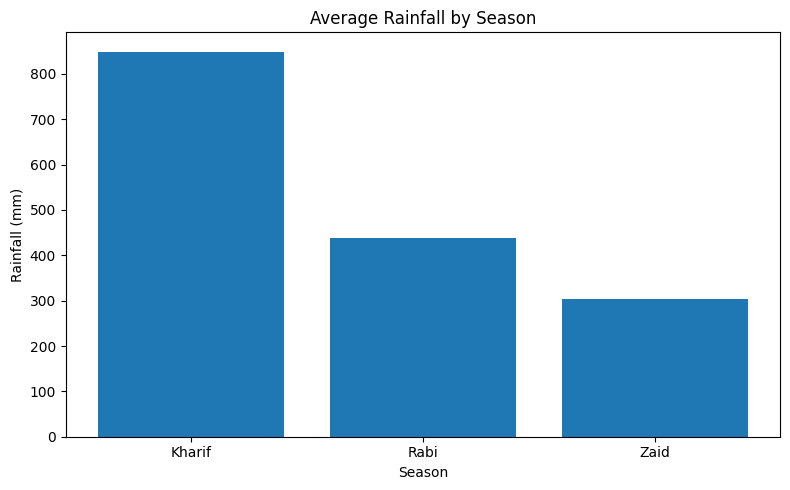

In [14]:
# ------------------------------------------------------------
# 14. CHART 4 - RAINFALL BY SEASON
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

rainfall = (
    data.groupby("Season")["Rainfall_mm"]
    .mean()
    .reindex(season_order)
)

plt.bar(
    rainfall.index,
    rainfall.values
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()

plt.savefig(
    "agriculture_results/04_rainfall_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
# ------------------------------------------------------------
# 15. WATER USAGE AND EFFICIENCY
# ------------------------------------------------------------

water_summary = data.groupby("Season").agg(
    Water_Used=("Water_Used_m3", "mean"),
    Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )
).round(2)

print("\nWater Analysis:")
display(water_summary)


Water Analysis:


,Water_Used,Water_Efficiency
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


In [16]:
# ============================================================
# 16. CROP × SEASON ANALYSIS
# ============================================================

crop_season = data.groupby(
    ["Crop", "Season"]
).agg(
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )
).reset_index()

print("\nCrop × Season Analysis:")
display(crop_season)


Crop × Season Analysis:


,Crop,Season,Median_Yield,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency
0,Chilli,Kharif,1.770,1.731459,9.543804e+05,1.494092e+06,3.259514
1,Chilli,Rabi,1.580,1.465031,6.385725e+05,1.140992e+06,2.885988
2,Chilli,Zaid,1.250,1.195312,4.486591e+05,9.944295e+05,2.203594
3,Cotton,Kharif,1.450,1.374512,2.169995e+05,7.137399e+05,2.130521
4,Cotton,Rabi,1.210,1.198358,1.073436e+05,6.377222e+05,1.937657
5,Cotton,Zaid,0.985,0.960217,-5.392534e+04,4.694639e+05,1.488924
6,Groundnut,Kharif,1.520,1.484974,1.082654e+05,5.944149e+05,3.584078
7,Groundnut,Rabi,1.310,1.233164,1.041654e+04,5.057603e+05,2.897073
8,Groundnut,Zaid,1.095,1.037778,-6.887250e+04,4.807966e+05,2.465259
9,Maize,Kharif,3.120,2.966410,-3.933267e+04,4.860470e+05,6.054615


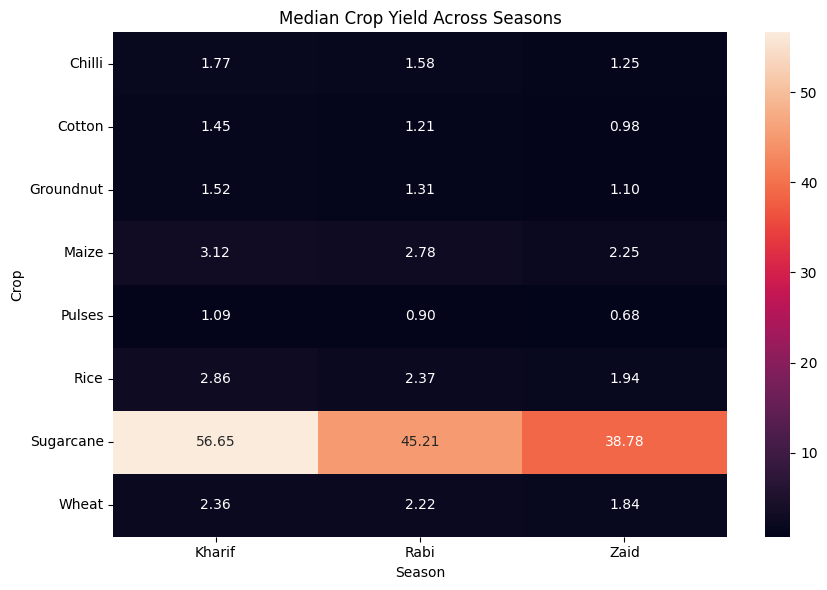

In [17]:
# ------------------------------------------------------------
# 17. CHART 5 - CROP SEASON HEATMAP
# ------------------------------------------------------------

yield_heatmap = crop_season.pivot(
    index="Crop",
    columns="Season",
    values="Median_Yield"
)

yield_heatmap = yield_heatmap[
    ["Kharif", "Rabi", "Zaid"]
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    yield_heatmap,
    annot=True,
    fmt=".2f"
)

plt.title("Median Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    "agriculture_results/05_crop_season_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [18]:
# ============================================================
# 18. IRRIGATION ANALYSIS
# ============================================================

irrigation_summary = data.groupby(
    ["Season", "Irrigation_Method"]
).agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Average_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )
).round(2)

print("\nIrrigation Analysis:")
display(irrigation_summary)


Irrigation Analysis:


Farms  Average_Yield  Average_Profit  Average_Water  \
Season Irrigation_Method                                                        
Kharif Drip                 405           7.26       317222.07        5953.37   
       Flood                590           4.98       133373.83        8229.27   
       Rainfed              463           5.70       158974.13        3687.52   
       Sprinkler            321           4.66       116880.49        5863.27   
Rabi   Drip                 370           6.11       187843.22        5911.41   
       Flood                526           5.06        58824.80        7766.83   
       Rainfed              438           3.93        45232.48        3298.29   
       Sprinkler            293           5.31        76502.07        6129.09   
Zaid   Drip                 140           5.85        21291.84        5837.99   
       Flood                194           3.98       -69786.78        8113.69   
       Rainfed              140           3.06       -79467.26        3879.39   
       Sprinkler            120           6.14        57909.40        7324.41   

                          Average_Efficiency  
Season Irrigation_Method                      
Kharif Drip                             6.80  
       Flood                            3.64  
       Rainfed                          8.85  
       Sprinkler                        4.62  
Rabi   Drip                             6.05  
       Flood                            3.48  
       Rainfed                          6.87  
       Sprinkler                        4.64  
Zaid   Drip                             5.30  
       Flood                            2.73  
       Rainfed                          5.48  
       Sprinkler                        4.86

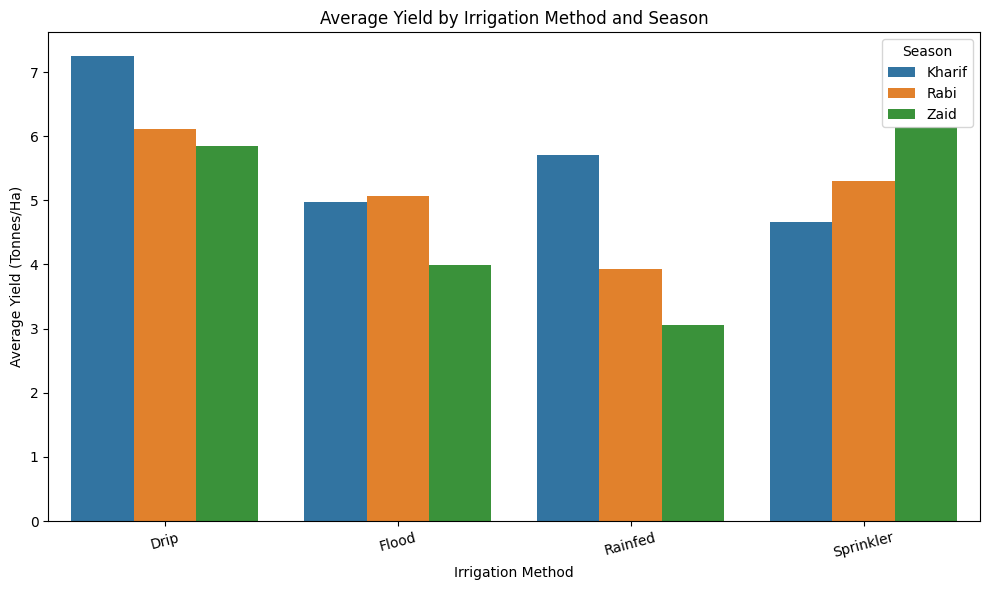

In [19]:
# ------------------------------------------------------------
# 19. CHART 6 - IRRIGATION VS YIELD
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "agriculture_results/06_irrigation_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

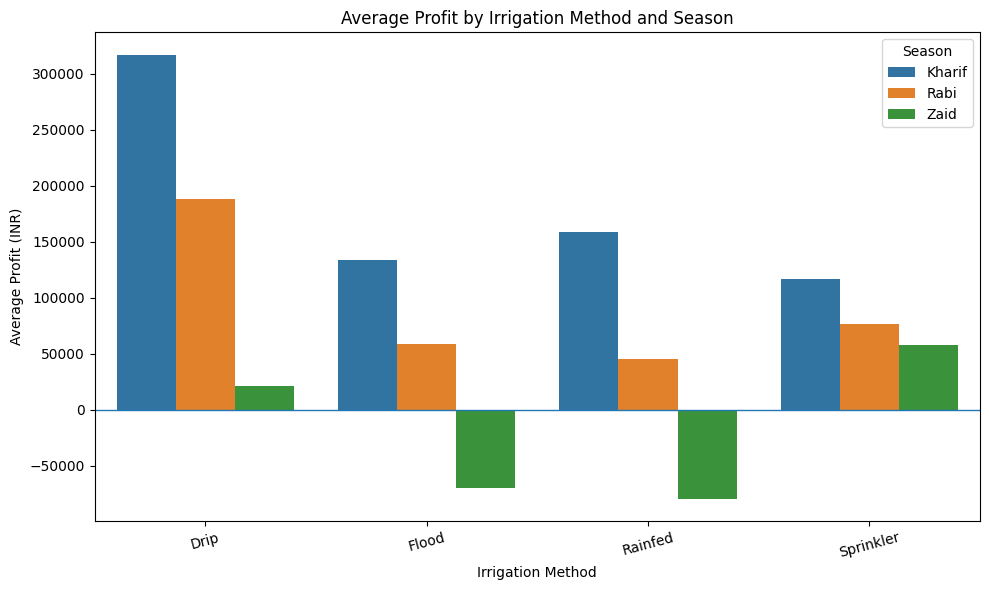

In [20]:

# ============================================================
# 20. IRRIGATION VS PROFIT
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x="Irrigation_Method",
    y="Profit_INR",
    hue="Season",
    estimator=np.mean,
    errorbar=None
)

plt.axhline(0, linewidth=1)

plt.title("Average Profit by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "agriculture_results/07_irrigation_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# 21. STATE-LEVEL ANALYSIS
# ============================================================

state_summary = data.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

state_summary = state_summary.sort_values(
    "Average_Profit",
    ascending=False
)

print("\nState-Level Analysis:")
display(state_summary)


State-Level Analysis:


,Farms,Average_Yield,Average_Profit,Water_Efficiency,Disease_Risk
State,,,,,
Punjab,484,6.12,136025.64,5.62,46.00
Maharashtra,512,5.02,135428.86,5.28,46.44
Karnataka,489,5.69,119422.34,5.56,46.06
Tamil Nadu,485,4.88,117744.75,5.31,46.28
Gujarat,488,5.66,117568.24,5.58,45.95
Telangana,516,5.04,108829.62,5.46,46.36
Madhya Pradesh,497,4.99,86840.76,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,5.03,46.72


In [22]:
# ============================================================
# 22. CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = data[
    correlation_columns
].corr()

# Correlation with Yield
yield_correlation = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

print("\nCorrelation with Yield:")
print(yield_correlation.round(3))


Correlation with Yield:
Yield_Tonnes_Ha                  1.000
Water_Efficiency_t_per_1000m3    0.913
Production_Tonnes                0.883
Profit_INR                       0.488
Revenue_INR                      0.432
Water_Used_m3                    0.386
Nitrogen_kg_ha                   0.053
Phosphorus_kg_ha                 0.048
Rainfall_mm                      0.031
Total_Cost_INR                   0.031
Disease_Pest_Risk_pct            0.014
Humidity_pct                     0.012
Soil_Moisture_pct                0.011
Avg_Temperature_C                0.010
Potassium_kg_ha                  0.003
Fertilizer_kg_ha                 0.000
Seed_Quality_Score              -0.007
Pesticide_Litre_ha              -0.008
Sunlight_Hours_Day              -0.015
Soil_pH                         -0.021
Market_Price_INR_Tonne          -0.383
Name: Yield_Tonnes_Ha, dtype: float64


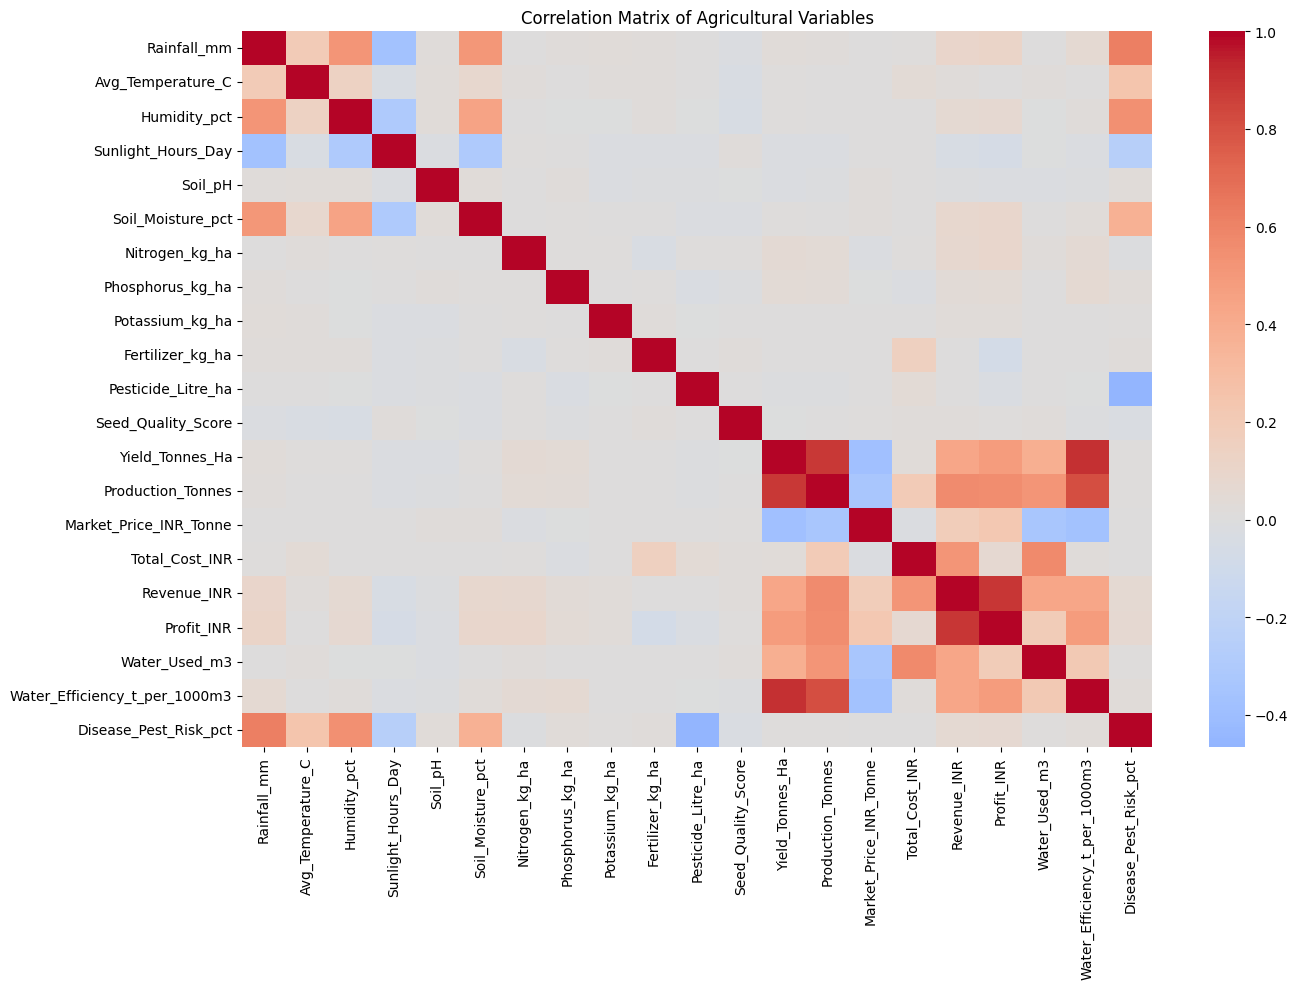

In [23]:
# ============================================================
# 23. CHART 8 - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()

plt.savefig(
    "agriculture_results/08_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

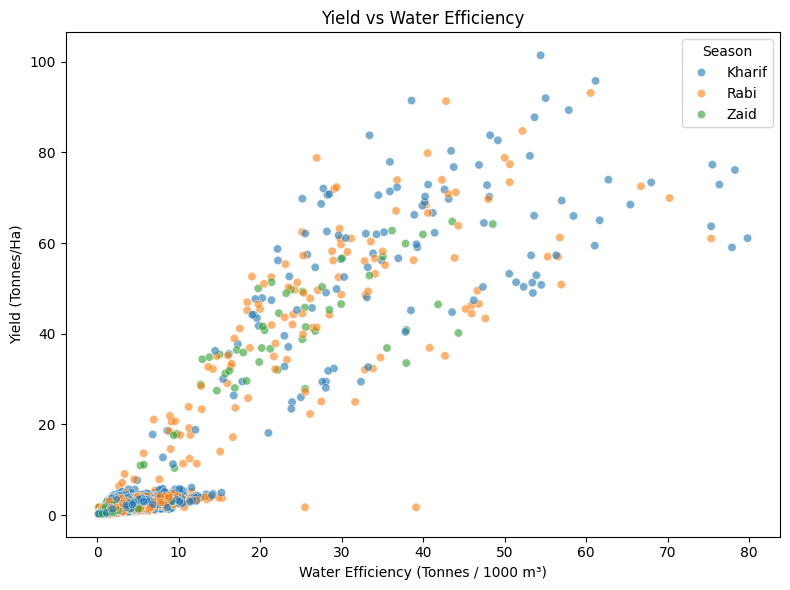

In [24]:
# ============================================================
# 24. YIELD VS WATER EFFICIENCY
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="Water_Efficiency_t_per_1000m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Yield vs Water Efficiency")
plt.xlabel("Water Efficiency (Tonnes / 1000 m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()

plt.savefig(
    "agriculture_results/09_yield_vs_water_efficiency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# 25. STATISTICAL TEST - KRUSKAL WALLIS
# ============================================================

season_yield_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for _, group in data.groupby("Season")
]

kruskal_yield = kruskal(*season_yield_groups)

print("\nKruskal-Wallis Test - Yield")
print("Statistic:", round(kruskal_yield.statistic, 4))
print("p-value:", kruskal_yield.pvalue)


Kruskal-Wallis Test - Yield
Statistic: 68.7131
p-value: 1.1999054760748268e-15


In [26]:
# ------------------------------------------------------------
# 26. PROFIT STATISTICAL TEST
# ------------------------------------------------------------

season_profit_groups = [
    group["Profit_INR"].dropna()
    for _, group in data.groupby("Season")
]

kruskal_profit = kruskal(*season_profit_groups)

print("\nKruskal-Wallis Test - Profit")
print("Statistic:", round(kruskal_profit.statistic, 4))
print("p-value:", kruskal_profit.pvalue)


Kruskal-Wallis Test - Profit
Statistic: 101.9261
p-value: 7.362721866797111e-23


In [27]:
# ============================================================
# 27. TOP PERFORMING CROP-SEASON COMBINATIONS
# ============================================================

top_crop_season = crop_season.sort_values(
    "Average_Profit",
    ascending=False
)

print("\nTop Crop-Season combinations by average profit:")
display(top_crop_season.head(10))


Top Crop-Season combinations by average profit:


,Crop,Season,Median_Yield,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency
18,Sugarcane,Kharif,56.65,53.459120,1.000791e+06,1.561828e+06,36.003912
0,Chilli,Kharif,1.77,1.731459,9.543804e+05,1.494092e+06,3.259514
19,Sugarcane,Rabi,45.21,43.286124,7.316129e+05,1.269755e+06,27.924581
1,Chilli,Rabi,1.58,1.465031,6.385725e+05,1.140992e+06,2.885988
20,Sugarcane,Zaid,38.78,38.423922,5.836358e+05,1.165236e+06,23.390784
2,Chilli,Zaid,1.25,1.195312,4.486591e+05,9.944295e+05,2.203594
3,Cotton,Kharif,1.45,1.374512,2.169995e+05,7.137399e+05,2.130521
6,Groundnut,Kharif,1.52,1.484974,1.082654e+05,5.944149e+05,3.584078
4,Cotton,Rabi,1.21,1.198358,1.073436e+05,6.377222e+05,1.937657
12,Pulses,Kharif,1.09,1.036063,4.333890e+04,5.902763e+05,3.352448


In [28]:
# ============================================================
# 28. LOWEST PERFORMING CROP-SEASON COMBINATIONS
# ============================================================

print("\nLowest Crop-Season combinations by average profit:")
display(top_crop_season.tail(10))


Lowest Crop-Season combinations by average profit:


,Crop,Season,Median_Yield,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency
15,Rice,Kharif,2.860,2.698376,-64903.404459,491546.108280,2.169255
8,Groundnut,Zaid,1.095,1.037778,-68872.500000,480796.574074,2.465259
10,Maize,Rabi,2.780,2.603648,-89133.403433,454728.038627,5.458416
16,Rice,Rabi,2.370,2.322847,-98427.868613,379818.700730,1.844153
21,Wheat,Kharif,2.360,2.253664,-105871.869863,431595.941781,4.758449
22,Wheat,Rabi,2.220,2.057468,-119954.565401,385277.835443,4.687430
14,Pulses,Zaid,0.675,0.669677,-139227.806452,351609.306452,1.950355
23,Wheat,Zaid,1.840,1.748588,-193208.952941,333265.152941,4.017000
11,Maize,Zaid,2.255,2.290952,-194049.166667,382831.297619,4.745940
17,Rice,Zaid,1.935,1.900490,-227239.343137,332144.382353,1.533069


In [29]:
# ============================================================
# 29. FINAL SUMMARY TABLE
# ============================================================

final_summary = pd.DataFrame({
    "Metric": [
        "Number of Farms",
        "Number of Seasons",
        "Number of Crops",
        "Number of States",
        "Number of Districts",
        "Number of Irrigation Methods",
        "Missing Values After Cleaning"
    ],
    "Value": [
        data["Farm_ID"].nunique(),
        data["Season"].nunique(),
        data["Crop"].nunique(),
        data["State"].nunique(),
        data["District"].nunique(),
        data["Irrigation_Method"].nunique(),
        data.isnull().sum().sum()
    ]
})

display(final_summary)

,Metric,Value
0,Number of Farms,4000
1,Number of Seasons,3
2,Number of Crops,8
3,Number of States,8
4,Number of Districts,10
5,Number of Irrigation Methods,4
6,Missing Values After Cleaning,0


In [30]:
# ============================================================
# 30. SAVE CLEANED DATA
# ============================================================

data.to_csv(
    "agriculture_results/cleaned_agriculture_dataset.csv",
    index=False
)

print("\nAnalysis completed successfully!")
print("All charts and cleaned data are available in:")
print("agriculture_results/")


Analysis completed successfully!
All charts and cleaned data are available in:
agriculture_results/


##Key Findings

## Seasonal Performance

- Kharif recorded the highest median yield.
- Kharif also showed the strongest average profitability.
- Zaid recorded the lowest median yield.
- Zaid had the weakest average economic performance.

## Environmental Conditions

- Kharif experienced the highest average rainfall.
- Zaid experienced the highest average temperature.
- Seasonal environmental conditions varied substantially.

## Water Resources

- Zaid showed the highest average water consumption.
- Kharif showed the highest average water efficiency.
- Water efficiency showed a strong relationship with yield.

## Crop Performance

- Kharif recorded the highest median yield for each crop.
- Sugarcane had substantially higher yield than the other crops.

## Irrigation

- Irrigation performance differed across seasons.
- Drip irrigation performed strongly in Kharif and Rabi.
- Sprinkler irrigation showed stronger results in Zaid.

## Statistical Analysis

- Seasonal yield distributions differed significantly.
- Seasonal profit distributions also differed significantly.

#Recommendations

Based on the observed patterns:

1. Seasonal agricultural planning should consider differences
   in environmental conditions.

2. Water efficiency should be considered when evaluating
   agricultural performance.

3. Irrigation strategies can be evaluated separately for
   different seasons rather than applying a single strategy
   throughout the year.

4. Crop selection can be informed by historical seasonal
   performance.

5. Further investigation should focus on low-performing
   crop-season combinations.

6. Additional multi-year and real-time weather data could
   improve future analysis and prediction.